# Modelo K-means

## Pregunta de investigación

¿De qué manera se modifican la estructura, consistencia y capacidad explicativa de los clústeres de estudiantes al aplicar diferentes valores de k (k=3, k=4, k=5) en el algoritmo K-Means, en relación con los factores psicológicos, sociales y académicos asociados a sus niveles de estrés?

## Objetivo General

Categorizar perfiles de estudiantes según sus niveles de estrés mediante técnicas de clustering (K-means), con el fin de comprender los factores psicológicos, sociales y académicos que inciden en su bienestar.

# Importanción de librerias

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset

In [2]:
df = pd.read_csv("StressLevelDataset.csv")

In [3]:
print(df.head())

   anxiety_level  self_esteem  mental_health_history  depression  headache  \
0             14           20                      0          11         2   
1             15            8                      1          15         5   
2             12           18                      1          14         2   
3             16           12                      1          15         4   
4             16           28                      0           7         2   

   blood_pressure  sleep_quality  breathing_problem  noise_level  \
0               1              2                  4            2   
1               3              1                  4            3   
2               1              2                  2            2   
3               3              1                  3            4   
4               3              5                  1            3   

   living_conditions  ...  basic_needs  academic_performance  study_load  \
0                  3  ...            2        

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

In [5]:
df.describe()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,...,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,...,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


In [6]:
df["stress_level"].value_counts() #3 grupos de stress_level

stress_level
0    373
2    369
1    358
Name: count, dtype: int64

# Evaluación de datos

In [7]:
# Revisar si hay valores nulos
print("Valores nulos por columna:\n", df.isnull().sum())

Valores nulos por columna:
 anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64


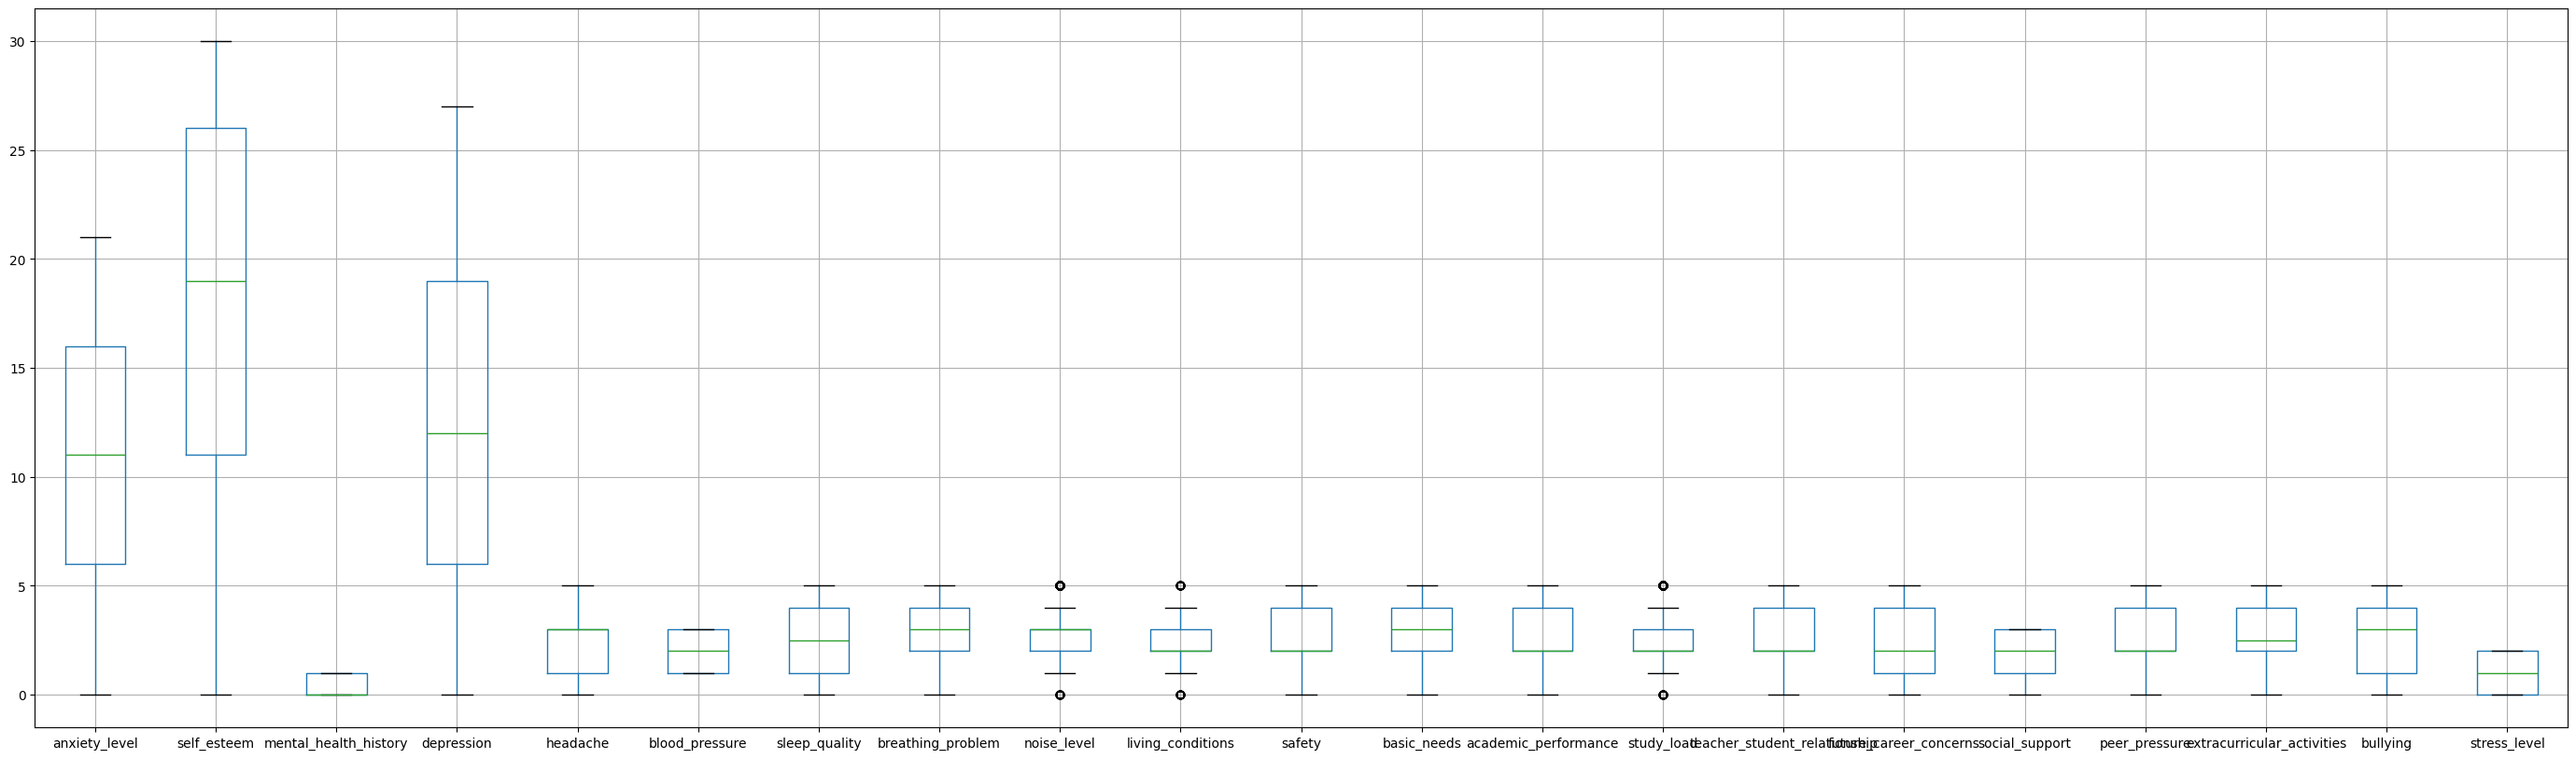

In [8]:
#Boxplot del fataframe
df.boxplot(figsize=(35,10))
plt.show()

In [9]:
#Identificacion de outliers para cada columna del dataframe usando el metodo IQR
cantidad_outliers = 0
for columna in df.columns:
  Q1 = df[columna].quantile(0.25)
  Q3 = df[columna].quantile(0.75)
  IQR = Q3 - Q1
  limite_inferior = Q1 - 1.5 * IQR
  limite_superior = Q3 + 1.5 * IQR
  outliers_mask = (df[columna] < limite_inferior) | (df[columna] > limite_superior)
  cantidad_outliers += outliers_mask.sum()
  print(f'CANTIDAD OUTLIERS PARA {columna}: {outliers_mask.sum()}')

print(f"\nCANTIDAD TOTAL DE OUTLIERS:{cantidad_outliers}")
print(f"PORCENTAJE DE OUTLIERS CON RESPECTO AL TOTAL DE DATOS ({len(df)}): {round((cantidad_outliers * 100)/len(df),2)} %")

CANTIDAD OUTLIERS PARA anxiety_level: 0
CANTIDAD OUTLIERS PARA self_esteem: 0
CANTIDAD OUTLIERS PARA mental_health_history: 0
CANTIDAD OUTLIERS PARA depression: 0
CANTIDAD OUTLIERS PARA headache: 0
CANTIDAD OUTLIERS PARA blood_pressure: 0
CANTIDAD OUTLIERS PARA sleep_quality: 0
CANTIDAD OUTLIERS PARA breathing_problem: 0
CANTIDAD OUTLIERS PARA noise_level: 173
CANTIDAD OUTLIERS PARA living_conditions: 62
CANTIDAD OUTLIERS PARA safety: 0
CANTIDAD OUTLIERS PARA basic_needs: 0
CANTIDAD OUTLIERS PARA academic_performance: 0
CANTIDAD OUTLIERS PARA study_load: 165
CANTIDAD OUTLIERS PARA teacher_student_relationship: 0
CANTIDAD OUTLIERS PARA future_career_concerns: 0
CANTIDAD OUTLIERS PARA social_support: 0
CANTIDAD OUTLIERS PARA peer_pressure: 0
CANTIDAD OUTLIERS PARA extracurricular_activities: 0
CANTIDAD OUTLIERS PARA bullying: 0
CANTIDAD OUTLIERS PARA stress_level: 0

CANTIDAD TOTAL DE OUTLIERS:400
PORCENTAJE DE OUTLIERS CON RESPECTO AL TOTAL DE DATOS (1100): 36.36 %


In [10]:
print(df["noise_level"].value_counts())
print(df["living_conditions"].value_counts())
print(df["study_load"].value_counts())


noise_level
2    313
3    289
1    188
4    137
5    137
0     36
Name: count, dtype: int64
living_conditions
2    346
3    327
4    189
1    176
5     33
0     29
Name: count, dtype: int64
study_load
2    333
3    275
1    185
4    142
5    128
0     37
Name: count, dtype: int64


## Tratamiento de valores nulos

In [11]:
# Para K-Means, eliminaremos filas con valores faltantes (alternativamente se puede imputar)
df_clean = df.dropna()

In [12]:
# Aquí todas las columnas excepto 'stress_level' se usarán como features
features = df_clean.drop(columns=['stress_level'])

## Escalar datos

In [13]:
# Escalar los datos para que todas las variables tengan la misma importancia
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

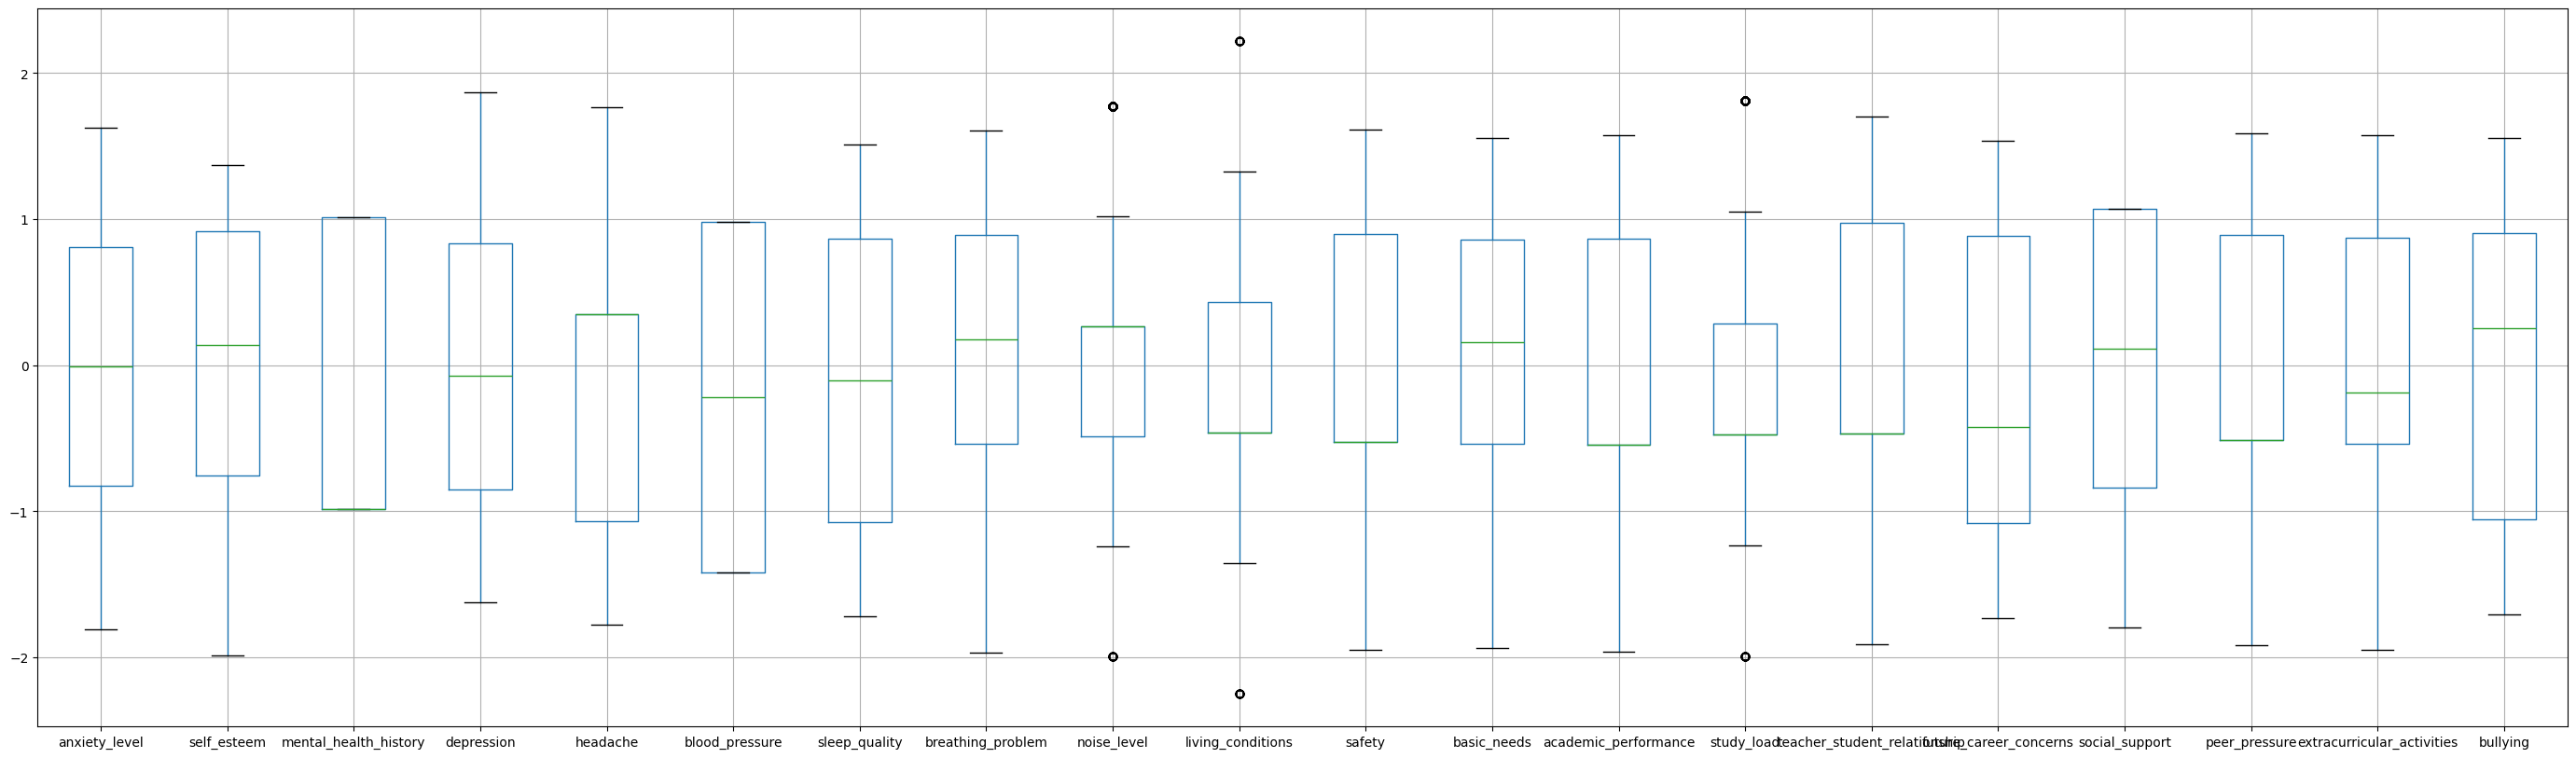

In [14]:
#Boxplot con el dataframe escalado
df_scaled = pd.DataFrame(X_scaled, columns=features.columns)
df_scaled.boxplot(figsize=(35,10))
plt.show()

# Optimización de clusters


## Metodo de Elbow

In [15]:
# Método del Elbow
wcss = []
K_range = range(1, 11)  # Probar de 1 a 10 clusters
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

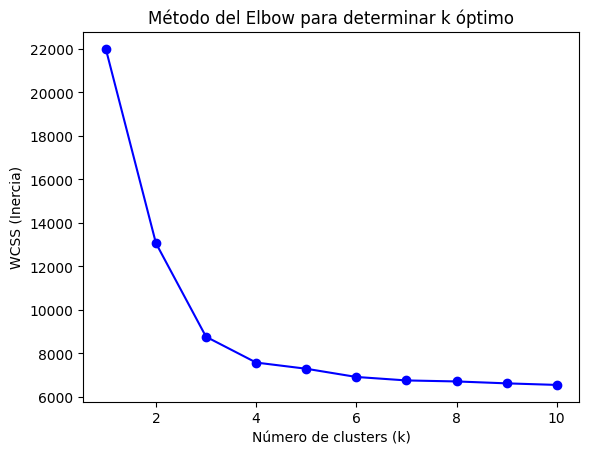

In [16]:
# Graficar el Elbow
plt.figure()
plt.plot(K_range, wcss, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('WCSS (Inercia)')
plt.title('Método del Elbow para determinar k óptimo')
plt.show()

## Metodo Silhouette Score

k optimo = 5


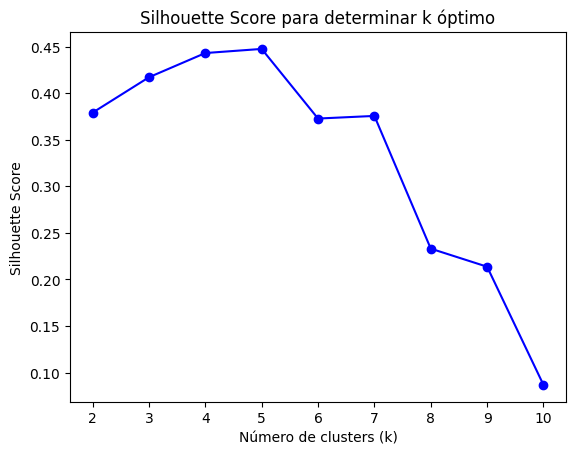

In [17]:
# Método del Silhouette Score
K_range = range(2, 11)
sil_scores = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, cluster_labels)
    sil_scores.append(sil_score)

print(f'k optimo = {2 + sil_scores.index(max(sil_scores))}')
plt.figure()
plt.plot(K_range, sil_scores, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score para determinar k óptimo')
plt.show()

# Evaluación de los metodos Silhouette Score y Elbow

## Implementación Elbow para modelo K-Means

Considerando k=3 segun Elbow

In [18]:
# Elegimos k=3 según Elbow
# En el gráfico de WCSS (inercia) vs número de clusters, buscamos el “codo” donde la reducción de WCSS empieza a ser menos pronunciada.
# El “codo” parece estar entre k=3 o k=4, porque después de eso, agregar clusters no reduce significativamente la inercia.

k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=42)
clusters = kmeans.fit_predict(X_scaled)


In [19]:
# Añadir la columna 'Cluster' al DataFrame original
df_clean['Cluster'] = clusters

## Visualización de Elbow

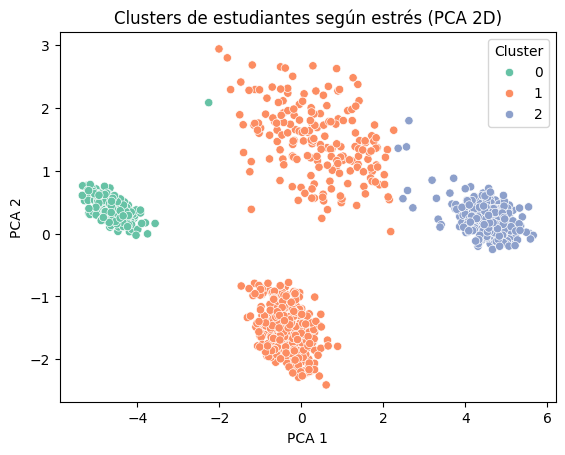

In [20]:
# Reducir dimensionalidad con PCA a 2 componentes para graficar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='Set2')
plt.title('Clusters de estudiantes según estrés (PCA 2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

In [21]:
print("Conteo de observaciones por cluster (k=3)")
print(df_clean["Cluster"].value_counts())

Conteo de observaciones por cluster (k=3)
Cluster
1    488
2    311
0    301
Name: count, dtype: int64


[[301  70   2]
 [  0 351   7]
 [  0  67 302]]
              precision    recall  f1-score   support

           0       1.00      0.81      0.89       373
           1       0.72      0.98      0.83       358
           2       0.97      0.82      0.89       369

    accuracy                           0.87      1100
   macro avg       0.90      0.87      0.87      1100
weighted avg       0.90      0.87      0.87      1100



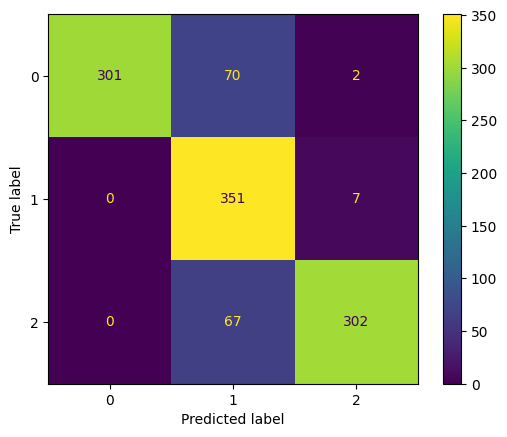

In [22]:
#HACER UNA MATRIZ DE CONFUSION PARA EVALUAR SI LOS CLUSTERS OBTENIDOS COINCIDEN CON LOS GRUPOS DE STRESS LEVEL
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(df_clean["stress_level"], df_clean["Cluster"])
print(cm)

#MOSTRAR LA MATRIZ CON DISPLAYCONFUSSIONMATRIX
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

#MOSTRAR EL CLASSIFICATION REPORT
from sklearn.metrics import classification_report
print(classification_report(df_clean["stress_level"], df_clean["Cluster"]))
disp.plot()
plt.show()


El modelo de **K-means** aplicado al dataset de *Student Stress Monitoring* mostró un desempeño sólido, alcanzando un **87% de exactitud** al comparar los clusters con las etiquetas reales de niveles de estrés. Los resultados evidencian que el algoritmo logró diferenciar con claridad los grupos, especialmente el de estrés medio, aunque se observa cierta confusión entre las categorías de **estrés medio y alto**, lo que es coherente con la naturaleza difusa de estas condiciones en contextos reales. En conjunto, estos resultados reflejan que K-means puede capturar patrones relevantes en los datos, pero también sugieren que técnicas más flexibles podrían mejorar la separación de clases con fronteras menos definidas.

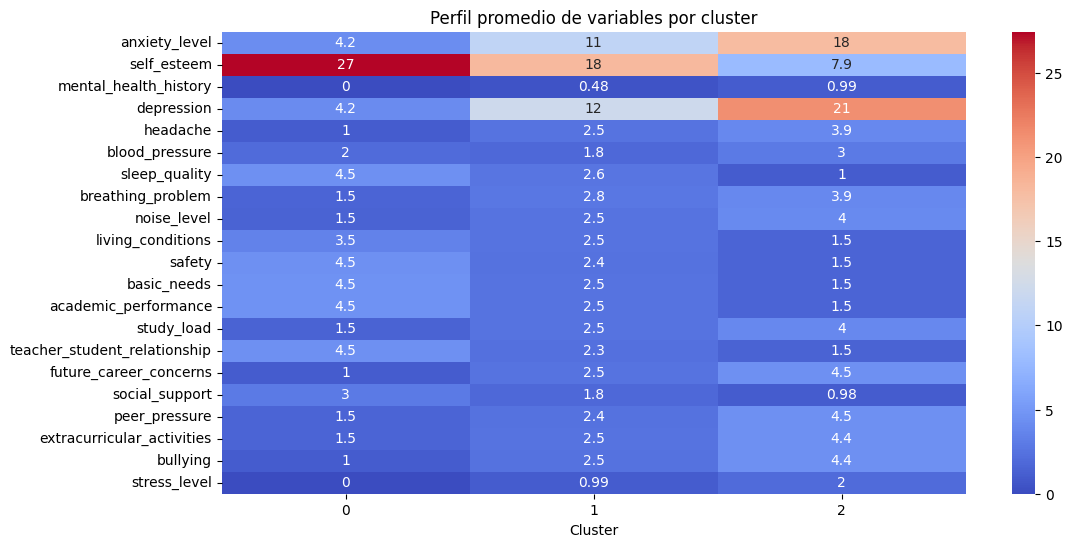

In [23]:
# Visualización del perfil promedio de cada cluster
cluster_means = df_clean.groupby('Cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means.T, annot=True, cmap='coolwarm')
plt.title('Perfil promedio de variables por cluster')
plt.show()

Los tres clusters muestran perfiles coherentes con niveles bajo, medio y alto de estrés. El Cluster 1 concentra a estudiantes con condiciones más saludables, mientras que el Cluster 0 refleja un grupo intermedio con alta ansiedad pero aún con entornos protectores. Finalmente, el Cluster 2 agrupa a quienes enfrentan mayor vulnerabilidad emocional y social, lo que coincide con los resultados de la matriz de confusión, donde la mayor confusión se dio entre los niveles medio y alto, ya que comparten varias variables críticas.

## Implementación Silhouette para modelo K-Means

Considerando k= 5  segun silhouette

In [24]:
k_opt_sil = 5
kmeans_sil = KMeans(n_clusters=k_opt_sil, random_state=42)
clusters_sil = kmeans_sil.fit_predict(X_scaled)

In [25]:
df_clean['Cluster_sil'] = clusters_sil

## Visualización de Silhouette

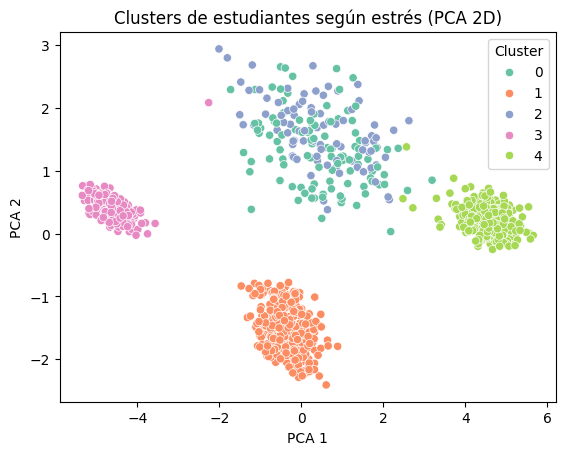

In [26]:
# Reducir dimensionalidad con PCA a 2 componentes para graficar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters_sil, palette='Set2')
plt.title('Clusters de estudiantes según estrés (PCA 2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

In [27]:
print("Conteo de observaciones por cluster (k=5)")
print(df_clean["Cluster_sil"].value_counts())

Conteo de observaciones por cluster (k=5)
Cluster_sil
4    307
3    301
1    300
0    106
2     86
Name: count, dtype: int64


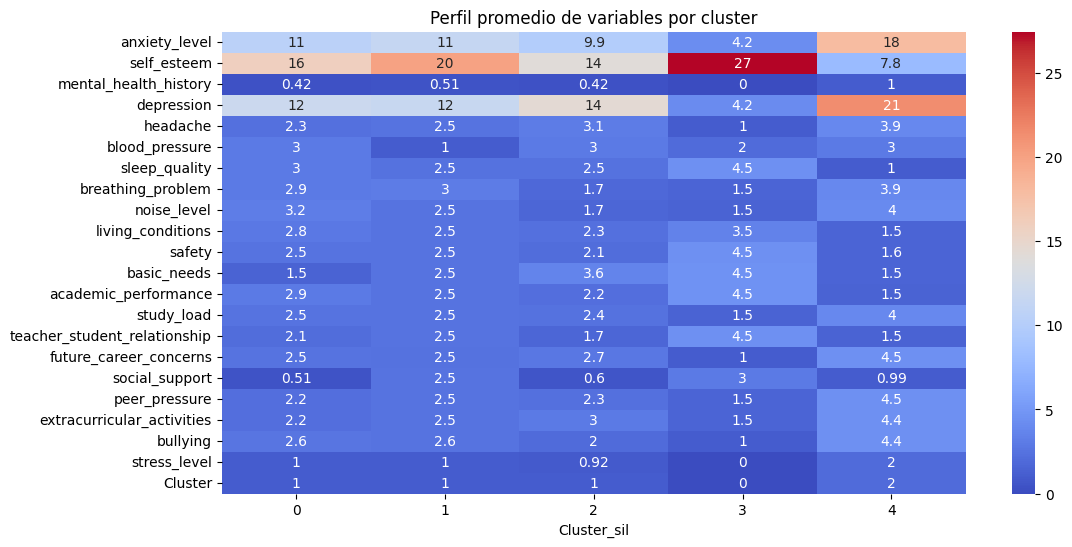

In [28]:
# Visualización del perfil promedio de cada cluster
cluster_means_sil = df_clean.groupby('Cluster_sil').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means_sil.T, annot=True, cmap='coolwarm')
plt.title('Perfil promedio de variables por cluster')
plt.show()

El análisis con silhouette sugiere que la población estudiantil no se divide solo en tres niveles de estrés (bajo, medio y alto), sino en cinco perfiles más matizados. Esto permite distinguir no solo a quienes tienen bajo o alto estrés, sino también subgrupos intermedios donde influyen factores protectores (autoestima, apoyo social) o factores de riesgo específicos (carga académica, bullying, historial de salud mental). Esta segmentación más detallada aporta una visión más rica para diseñar estrategias de intervención diferenciadas en función de las necesidades de cada grupo.

## Conclusión comparativa

El análisis comparativo entre los modelos con **k=3 y k=5** muestra que, aunque con tres clusters se logró una clasificación coherente en niveles de **bajo, medio y alto estrés**, el uso del **método silhouette** reveló que una partición en cinco grupos ofrece una caracterización más rica y matizada de la población estudiantil. Con k=5 fue posible identificar subgrupos intermedios, donde algunos estudiantes presentan **estrés moderado asociado principalmente a factores emocionales**, otros reflejan **estrés derivado de la carga académica**, mientras que un grupo reducido destaca por su **alta resiliencia y baja sintomatología**. En contraste, el clúster de mayor vulnerabilidad concentra a quienes exhiben altos niveles de ansiedad, depresión, baja autoestima y múltiples problemas sociales y físicos. En conjunto, esta segmentación más detallada aporta **mayor valor interpretativo** para comprender la diversidad de condiciones que influyen en el bienestar estudiantil y sugiere que las intervenciones deben diseñarse de manera **específica y diferenciada según las características de cada grupo**.


# Cluster promedio entre Silhouette y Elbow k=4

En el análisis del número óptimo de clusters mediante el **método del codo**, se observó un punto de inflexión marcado en **k=3 y k=4**, lo que indica que ambos valores son adecuados para representar la estructura de los datos. Sin embargo, se optó por **k=4** ya que permite una segmentación más equilibrada: por un lado, conserva la simplicidad interpretativa del modelo de tres grupos (bajo, medio y alto nivel de estrés), y por otro, añade un nivel intermedio que ayuda a capturar con mayor precisión a los estudiantes que presentan características difusas entre el estrés medio y alto. De esta forma, el modelo con cuatro clusters entrega una clasificación más detallada y práctica para el análisis, sin llegar a la complejidad que implica trabajar con cinco grupos.


In [29]:
k_mean = 4
kmeans_m = KMeans(n_clusters=k_mean, random_state=42)
clusters_m = kmeans_m.fit_predict(X_scaled)

In [30]:
df_clean['Cluster_m'] = clusters_m

### Visualización clusters promedio

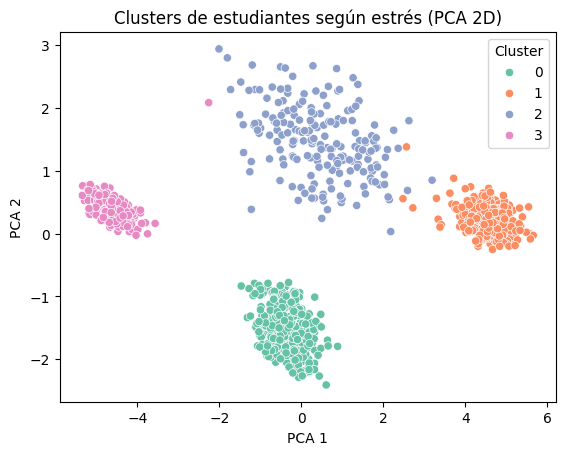

In [31]:
# Reducir dimensionalidad con PCA a 2 componentes para graficar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters_m, palette='Set2')
plt.title('Clusters de estudiantes según estrés (PCA 2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

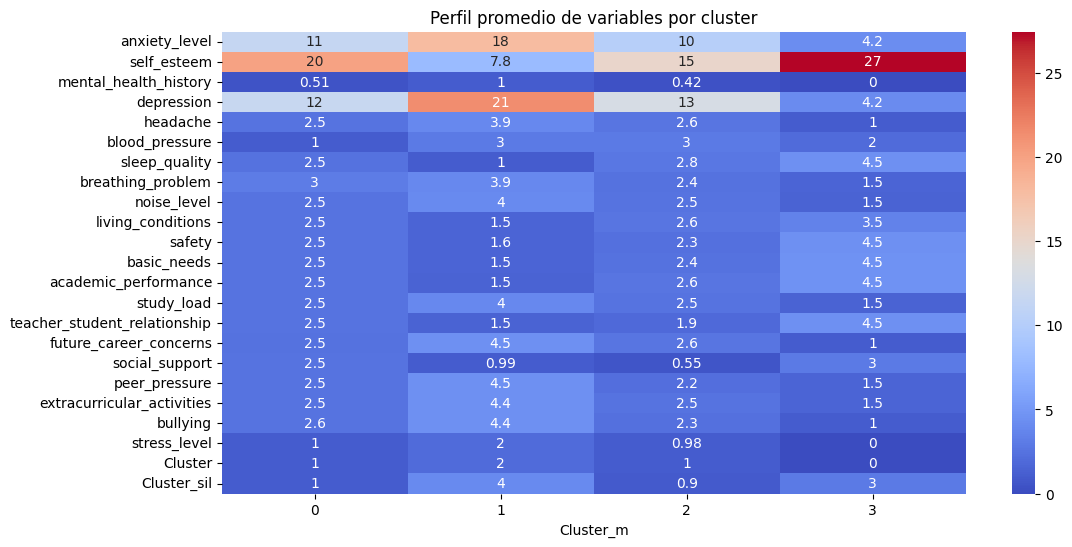

In [32]:
# Visualización del perfil promedio de cada cluster
cluster_means_m = df_clean.groupby('Cluster_m').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means_m.T, annot=True, cmap='coolwarm')
plt.title('Perfil promedio de variables por cluster')
plt.show()

### Conclusión

La elección de **k=4** resultó adecuada para segmentar a los estudiantes en perfiles claramente diferenciados, como lo evidencian tanto la visualización con **PCA**, donde los grupos aparecen bien definidos, como el **perfil promedio de variables**, que muestra patrones consistentes. Los cuatro clusters se distribuyen en: (1) un grupo con **estrés moderado pero con buena autoestima**, (2) un grupo con **estrés alto y marcada vulnerabilidad emocional y física**, (3) un grupo de **estrés leve con síntomas controlados**, y (4) un grupo con **bajo estrés y alta resiliencia**. Esta clasificación ofrece una visión más matizada que la obtenida con tres clusters, ya que permite distinguir entre estudiantes con altos niveles de estrés según sus recursos emocionales disponibles. En consecuencia, el modelo con cuatro clusters no solo mejora la **precisión interpretativa**, sino que también aporta información más práctica para diseñar **estrategias de apoyo diferenciadas** según las necesidades de cada perfil.


# Conclusión Final

El análisis comparativo de los modelos de clustering con **k=3, k=4 y k=5** permitió identificar diferencias significativas en la forma de segmentar a los estudiantes según su nivel de estrés y características asociadas. Con **k=3**, la clasificación se ajusta al esquema tradicional de **bajo, medio y alto estrés**, lo cual facilita la interpretación general, pero genera solapamientos, especialmente entre los niveles medio y alto. Con **k=5**, el método silhouette logra una separación más fina y distingue subgrupos intermedios (ej. estrés académico o perfiles emocionales específicos), pero la complejidad de interpretación aumenta, lo que puede dificultar la aplicación práctica. En cambio, el modelo con **k=4** ofrece un equilibrio óptimo: la visualización con PCA mostró clusters bien definidos y el heatmap evidenció perfiles diferenciados entre **estrés alto con vulnerabilidad**, **estrés moderado con autoestima protectora**, **estrés leve**, y **bajo estrés con alta resiliencia**. Por lo tanto, el modelo de cuatro clusters representa la solución más adecuada, al aportar tanto **claridad interpretativa** como **riqueza en la caracterización de perfiles**, lo que resulta especialmente útil para diseñar intervenciones de apoyo más focalizadas.